In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('dynamic_pricing.csv')
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [2]:
df.info()
print(50*'-')
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   str    
 3   Customer_Loyalty_Status  1000 non-null   str    
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   str    
 7   Vehicle_Type             1000 non-null   str    
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), str(4)
memory usage: 103.3 KB
--------------------------------------------------


Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64

Cleaning and Preparing Dataset

"First, we enforce numeric data types on all critical columns, converting invalid entries to NaN. 

Second, we correct illogical data points by replacing the Average_Ratings of first-time riders (zero past rides) with the dataset's global mean. 

Finally, we engineer two new variables, Cost_per_Minute and Supply_and_Demand, to facilitate our business analysis."

In [3]:
import numpy as np
import pandas as pd

# The new version standardizes text, checks ranges, removes duplicates,
# creates operational flags, avoids modifying the original DataFrame directly, and handles zero-driver cases more accurately.

NUMERIC_COLUMNS = [
    'Number_of_Riders',
    'Number_of_Drivers',
    'Number_of_Past_Rides',
    'Average_Ratings',
    'Expected_Ride_Duration',
    'Historical_Cost_of_Ride'
]

CATEGORICAL_COLUMNS = [
    'Location_Category',
    'Customer_Loyalty_Status',
    'Time_of_Booking',
    'Vehicle_Type'
]


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    # Does not overwrite df
    cleaned = df.copy()

    # Standardize column names (just in case)
    cleaned.columns = cleaned.columns.str.strip()

    # Throws error if there are missing cols
    required_columns = set(NUMERIC_COLUMNS + CATEGORICAL_COLUMNS)
    missing_columns = required_columns - set(cleaned.columns)
    if missing_columns:
        raise ValueError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    # Convert all numerical fields
    for column in NUMERIC_COLUMNS:
        cleaned[column] = pd.to_numeric(
            cleaned[column],
            errors='coerce'
        )

    # Clean categorical values
    for column in CATEGORICAL_COLUMNS:
        cleaned[column] = (
            cleaned[column]
            .astype('string') #convert to pandas string
            .str.strip() #strip surrounding spaces
            .str.title() #standardize capitalization
        )

    # Remove duplicate rows
    # debug code to see how many were removed
    duplicate_count = cleaned.duplicated().sum()
    print(f"Duplicate rows removed: {duplicate_count}")
    cleaned = cleaned.drop_duplicates()

    # Validate numerical ranges, checks for:
    cleaned.loc[ #if row, col val is < 0, make it nan
        cleaned['Number_of_Riders'] < 0, # negative riders makes no sense
        'Number_of_Riders'
    ] = np.nan

    cleaned.loc[
        cleaned['Number_of_Drivers'] < 0, #negative drivers
        'Number_of_Drivers'
    ] = np.nan

    cleaned.loc[
        cleaned['Expected_Ride_Duration'] <= 0, #negative duration
        'Expected_Ride_Duration'
    ] = np.nan

    cleaned.loc[
        ~cleaned['Average_Ratings'].between(1, 5), #invalid ratings
        'Average_Ratings'
    ] = np.nan

    cleaned.loc[
        cleaned['Number_of_Past_Rides'] < 0, #row
        'Number_of_Past_Rides' #col
    ] = np.nan

    cleaned.loc[
        cleaned['Historical_Cost_of_Ride'] < 0,
        'Historical_Cost_of_Ride'
    ] = np.nan

    # Mark first-time customers with a flag
    cleaned['Is_New_Customer'] = (
        cleaned['Number_of_Past_Rides'] == 0
    ).astype(int)

    # Fill only genuinely missing ratings, and point out where it was missing
    cleaned['Rating_Was_Missing'] = (
        cleaned['Average_Ratings'].isna()
    ).astype(int)

    cleaned['Average_Ratings'] = (
        cleaned['Average_Ratings']
        .fillna(cleaned['Average_Ratings'].median()) #fill with median instead, better in case of outliers
    )

    # Flag if there is no driver available
    cleaned['No_Drivers_Available'] = (
        cleaned['Number_of_Drivers'] == 0
    ).astype(int)

    essential_columns = [
        'Number_of_Riders',
        'Number_of_Drivers',
        'Number_of_Past_Rides',
        'Expected_Ride_Duration',
        'Historical_Cost_of_Ride'
    ]

    # check if there is at least 1 missing value in a row, then sum where there is
    invalid_row_count = cleaned[essential_columns].isna().any(axis=1).sum()
    print(f"Rows removed due to invalid essential values: {invalid_row_count}")

    cleaned = cleaned.dropna(subset=essential_columns)

    # Demand-to-supply ratio
    # if drivers are 0, ratio becomes nan, rather than assuming a driver
    cleaned['Supply_and_Demand'] = np.where(
        cleaned['Number_of_Drivers'] > 0, #condition
        cleaned['Number_of_Riders'] #val if true
        / cleaned['Number_of_Drivers'],
        np.nan #val if false
    )

    # No longer included in model prediction, still calcualted the same way
    cleaned['Cost_per_Minute'] = (
        cleaned['Historical_Cost_of_Ride']
        / cleaned['Expected_Ride_Duration']
    )


    # All colums returned are:
        # Is_New_Customer
        # No_Drivers_Available
        # Supply_and_Demand
        # Cost_per_Minute
        # Rating_Was_Missing
    return cleaned

df = clean_data(df)

Duplicate rows removed: 0
Rows removed due to invalid essential values: 0


In [4]:
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Is_New_Customer,Rating_Was_Missing,No_Drivers_Available,Supply_and_Demand,Cost_per_Minute
0,90.0,45.0,Urban,Silver,13.0,4.47,Night,Premium,90.0,284.257273,0,0,0,2.000000,3.158414
1,58.0,39.0,Suburban,Silver,72.0,4.06,Evening,Economy,43.0,173.874753,0,0,0,1.487179,4.043599
2,42.0,31.0,Rural,Silver,0.0,3.99,Afternoon,Premium,76.0,329.795469,1,0,0,1.354839,4.339414
3,89.0,28.0,Rural,Regular,67.0,4.31,Afternoon,Premium,134.0,470.201232,0,0,0,3.178571,3.508964
4,78.0,22.0,Rural,Regular,74.0,3.77,Afternoon,Economy,149.0,579.681422,0,0,0,3.545455,3.890479


In [5]:
print(df['Location_Category'].unique())
print(df['Vehicle_Type'].unique())
print(df['Time_of_Booking'].unique())

<ArrowStringArray>
['Urban', 'Suburban', 'Rural']
Length: 3, dtype: string
<ArrowStringArray>
['Premium', 'Economy']
Length: 2, dtype: string
<ArrowStringArray>
['Night', 'Evening', 'Afternoon', 'Morning']
Length: 4, dtype: string


Visualizations

Time of Booking Distribution

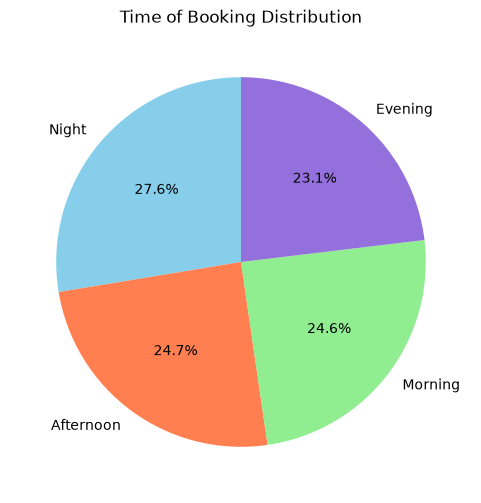

In [6]:
time_of_booking_counts = df['Time_of_Booking'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(time_of_booking_counts, labels=time_of_booking_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'coral', 'lightgreen', 'mediumpurple' ]) 
plt.title('Time of Booking Distribution')
plt.show()

Demands in detail depending on Car Type and Time

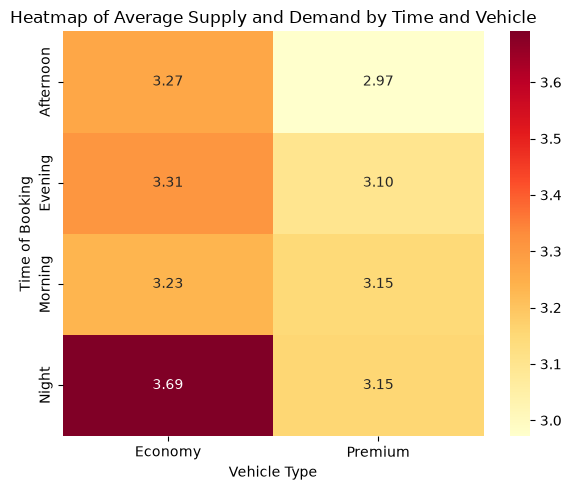

In [7]:
import seaborn as sns
heatmap_data = df.pivot_table(
    values = 'Supply_and_Demand',
    index = 'Time_of_Booking',
    columns = 'Vehicle_Type',
    aggfunc = 'mean')
plt.figure(figsize=(6,5))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt='.2f')

plt.title('Heatmap of Average Supply and Demand by Time and Vehicle')
# plt.xlabel('Location Category')
plt.xlabel('Vehicle Type') # fixed small label inconsistency
plt.ylabel('Time of Booking')
plt.tight_layout()
plt.show()

Vehicle Type Distribution

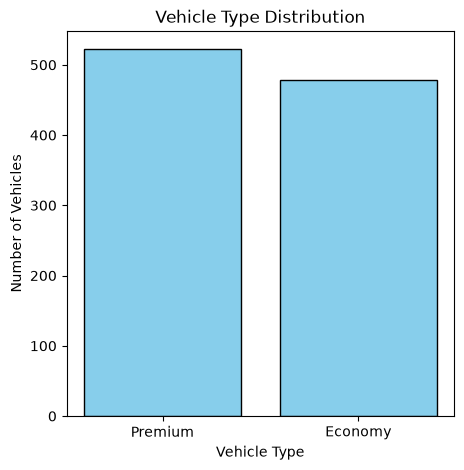

In [8]:
vehicle_counts = df['Vehicle_Type'].value_counts()
plt.figure(figsize=(5, 5))
plt.bar(vehicle_counts.index, vehicle_counts.values, color='skyblue', edgecolor='black')
plt.title('Vehicle Type Distribution')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Vehicles')
plt.show()

Average Supply and Demand depending on the Time of Booking

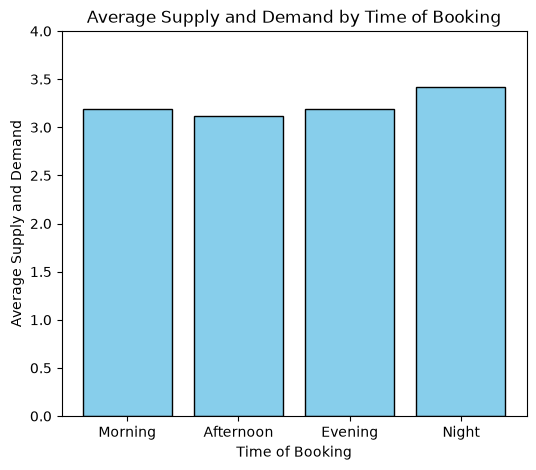

In [9]:
order_times = ['Morning', 'Afternoon', 'Evening', 'Night']
df['Time_of_Booking'] = pd.Categorical(df['Time_of_Booking'], categories=order_times, ordered=True)
average_supply_demand = df.groupby('Time_of_Booking')['Supply_and_Demand'].mean()
plt.figure(figsize=(6, 5))
plt.bar(average_supply_demand.index, average_supply_demand.values, color='skyblue', edgecolor='black')
plt.ylim(0, 4)
plt.title('Average Supply and Demand by Time of Booking')
plt.xlabel('Time of Booking')
plt.ylabel('Average Supply and Demand') 
plt.show()

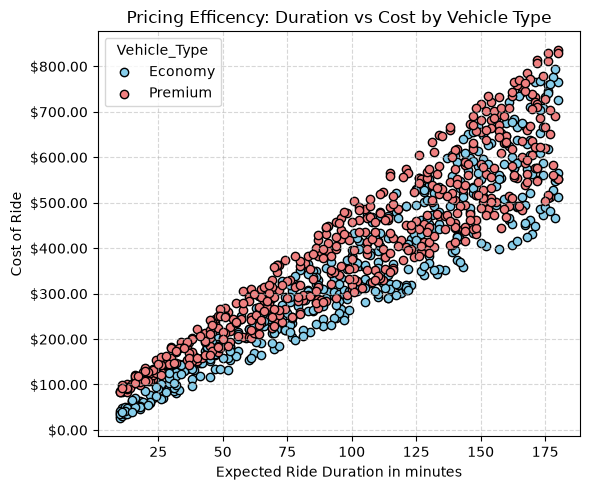

In [10]:
import matplotlib.ticker as ticker
plt.figure(figsize=(6, 5))
premium_df = df[df['Vehicle_Type'] == 'Premium']
economy_df = df[df['Vehicle_Type'] == 'Economy']

plt.scatter(
    economy_df['Expected_Ride_Duration'],
    economy_df['Historical_Cost_of_Ride'],
    color = 'skyblue',
    label = 'Economy',
    edgecolor = 'black',
)
plt.scatter(
    premium_df['Expected_Ride_Duration'],
    premium_df['Historical_Cost_of_Ride'],
    color = 'lightcoral',
    label = 'Premium',
    edgecolor = 'black',
)
plt.title('Pricing Efficency: Duration vs Cost by Vehicle Type')
plt.xlabel('Expected Ride Duration in minutes')
plt.ylabel('Cost of Ride')
plt.legend(title='Vehicle_Type')
plt.grid(True, linestyle='--', alpha=0.5)
formatter = ticker.StrMethodFormatter('${x:,.2f}')
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.show()

Average Ride Cost by Time of Booking

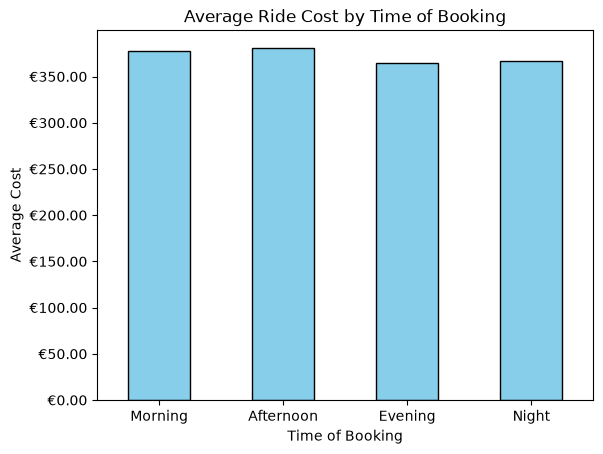

In [11]:
import matplotlib.ticker as ticker
avg_revenue = df.groupby('Time_of_Booking')['Historical_Cost_of_Ride'].mean()
ax = avg_revenue.plot(kind='bar', color='skyblue', edgecolor='black')
formatter = ticker.StrMethodFormatter('€{x:,.2f}')
ax.yaxis.set_major_formatter(formatter)
# plt.title('Average Revenue by Time of Booking')
plt.title('Average Ride Cost by Time of Booking') # more fitting title
plt.xlabel('Time of Booking')
# plt.ylabel('Average Revenue')
plt.ylabel('Average Cost')
plt.xticks(rotation=0) 
plt.show()

Average Supply and Demand by Region

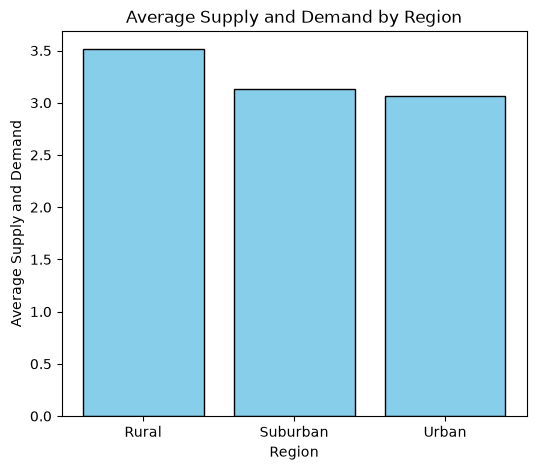

In [12]:
supply_demand_location = df.groupby('Location_Category')['Supply_and_Demand'].mean()
plt.figure(figsize=(6, 5))
plt.bar(supply_demand_location.index, supply_demand_location.values, color='skyblue', edgecolor='black')
plt.title('Average Supply and Demand by Region')
plt.xlabel('Region')
plt.ylabel('Average Supply and Demand')
plt.show()

Cost per Minute Depending on Location and wether it is an 'Economy' or 'Premium' vehicle

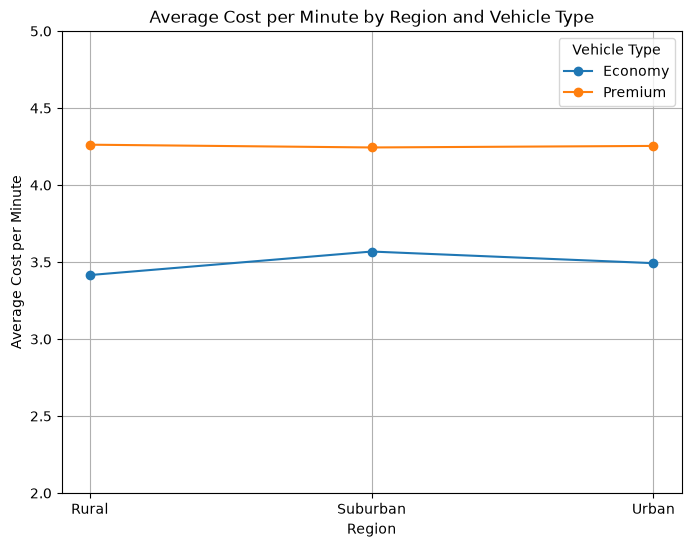

In [13]:
summary_df = df.groupby(['Location_Category', 'Vehicle_Type'])['Cost_per_Minute'].mean().unstack()
plt.figure(figsize=(8, 6))
for vehicle in summary_df.columns:
    plt.plot(summary_df.index, summary_df[vehicle], marker='o', label=vehicle)
plt.title('Average Cost per Minute by Region and Vehicle Type')
plt.xlabel('Region')
plt.ylabel('Average Cost per Minute')
plt.legend(title='Vehicle Type')
plt.ylim(2, 5)
plt.grid()
plt.show()

Prediction Historical Cost of Ride

First Part defines features and targets. Then we train the algorithm in a splitted data and gives us the accuracy in which the features impact the Historical Cost of Ride.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# Difference from old version:
# Encodes customer loyalty status as well, so we can use it as predictor
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Vehicle_Type',
        'Location_Category',
        'Time_of_Booking',
        'Customer_Loyalty_Status'
    ],
    drop_first=True
)

# Creating predictor table
# Difference from old version:
# remove columns directly from df_encoded
# we drop cost_per_minute too
X = df_encoded.drop(
    columns=[
        'Historical_Cost_of_Ride',
        'Cost_per_Minute' # also fixed typo of Cost_Per_Minute
    ]
)

# same logic as before, just uses column name directly
y = df_encoded['Historical_Cost_of_Ride']

# Difference from old version:
# features was created before X like: 
# features = [
#     col for col in df_encoded.columns
#     if col not in drop_cols
# ]
# 
# in new version X is created first, and feature names are taken directly from X
# safer, feature is guaranteed to match cols used to train model
features = X.columns.tolist()

# Differenc from old version:
# Uses X instead of x, because of naming conventions, but still the same 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

predictions = random_forest_model.predict(X_test)

r2 = r2_score(y_test, predictions)

print(f"R-Squared: {r2:.2%}")

R-Squared: 84.68%


### Model Evaluation
The performance of the Random Forest model is evaluated using several regression metrics. Besides the R-Squared score, Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) are calculated to provide a more comprehensive evaluation of prediction accuracy.


### Evaluation Metrics

In [15]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

predictions = random_forest_model.predict(X_test) # changed x to X

# Evaluation Metrics

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"R-Squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

R-Squared (R²): 0.8468
Mean Absolute Error (MAE): $55.52
Root Mean Squared Error (RMSE): $73.51


### Predicted vs Actual Prices

To further evaluate the prediction quality, the predicted ride prices are compared with the actual historical ride prices. In this plot, each point represents one ride from the test dataset. If the model performs well, the points should be close to the diagonal reference line. This means that the predicted values are close to the actual values.

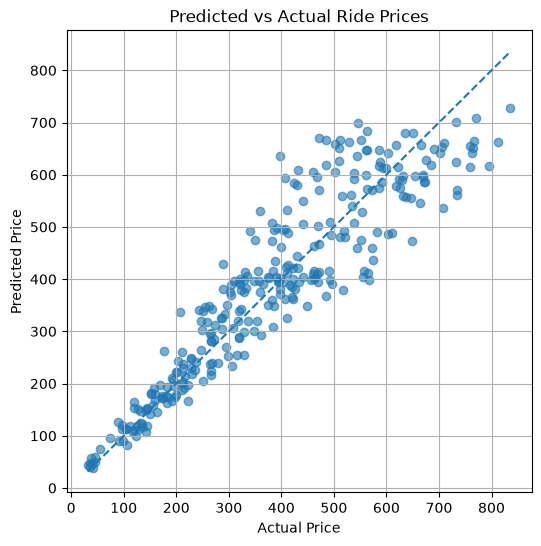

In [16]:
# Predicted vs Actual Prices

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)

min_price = min(y_test.min(), predictions.min())
max_price = max(y_test.max(), predictions.max())

plt.plot([min_price, max_price], [min_price, max_price], linestyle='--')
plt.title('Predicted vs Actual Ride Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

### Feature Importance

The Random Forest model can also show how important each input feature is for predicting ride prices. Feature importance helps us understand which factors have the strongest influence on the final ride cost. This is especially useful for a dynamic pricing project because it shows whether variables such as ride duration, supply and demand, vehicle type, location, or booking time have a strong effect on price prediction.

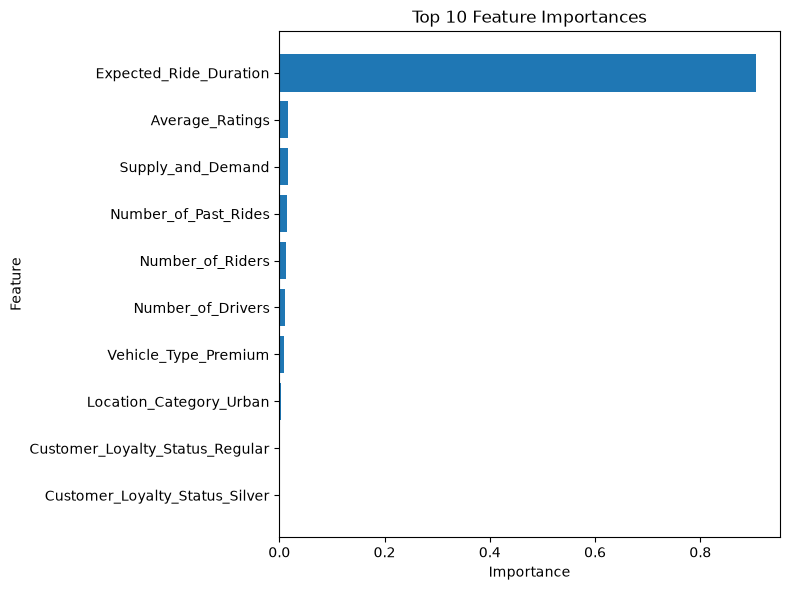

,Feature,Importance
4,Expected_Ride_Duration,0.906141
3,Average_Ratings,0.016308
8,Supply_and_Demand,0.016012
2,Number_of_Past_Rides,0.014899
0,Number_of_Riders,0.013645
1,Number_of_Drivers,0.011509
9,Vehicle_Type_Premium,0.009782
11,Location_Category_Urban,0.002407
15,Customer_Loyalty_Status_Regular,0.001905
16,Customer_Loyalty_Status_Silver,0.001761


In [17]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top_features = feature_importance.head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

top_features

### Interpretation of Model Evaluation

The model evaluation shows how well the Random Forest model can predict historical ride prices. The R-Squared score gives an overall indication of how much variation in ride prices is explained by the model. MAE and RMSE describe the average prediction error in price units.

The predicted vs actual plot provides a visual check of model performance. Points closer to the diagonal line indicate better predictions. The feature importance chart helps identify the most influential variables in the pricing model. These results are useful for understanding which factors contribute most to ride price changes and therefore support the development of a dynamic pricing strategy.

In the second part we create the function that creates the input data that we give to the algorithm that returns the predicted price

In [18]:
def predict_ride_cost(duration, riders, drivers, time_of_day, vehicle, location):
    data_dict = {col: 0 for col in features}
    
    if 'Expected_Ride_Duration' in data_dict:
        data_dict['Expected_Ride_Duration'] = duration
    if 'Number_of_Riders' in data_dict:
        data_dict['Number_of_Riders'] = riders
    if 'Number_of_Drivers' in data_dict:
        data_dict['Number_of_Drivers'] = drivers
    if 'Supply_and_Demand' in data_dict:
        data_dict['Supply_and_Demand'] = riders / drivers if drivers > 0 else riders
    
    vehicle_col = f'Vehicle_Type_{vehicle}'
    location_col = f'Location_Category_{location}'
    time_col = f'Time_of_Booking_{time_of_day}'
    
    if vehicle_col in data_dict:
        data_dict[vehicle_col] = 1
    if location_col in data_dict:
        data_dict[location_col] = 1
    if time_col in data_dict:
        data_dict[time_col] = 1
        
    input_data = pd.DataFrame([data_dict])
    predicted_price = random_forest_model.predict(input_data)[0]
    
    return predicted_price


Test Algorithm

In [19]:
test_price = predict_ride_cost(
    duration=15, 
    riders=40, 
    drivers=20, 
    time_of_day='Afternoon', 
    vehicle='Economy', 
    location='Urban'   )

print(f"Predicted Price is ${test_price:.2f}.")

Predicted Price is $57.16.
